In [44]:
#PACKAGES
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)

In [45]:
# LOAD & COMBINE
files = glob.glob("clean_data/*_final.parquet")

df_list = []
for file in files:
    temp = pd.read_parquet(file)
    coin_name = file.split("/")[-1].replace(".parquet", "").replace("_final", "")
    temp["coin"] = coin_name
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])

END_DATE = pd.Timestamp("2022-05-10")
df = df[df["timestamp"] <= END_DATE].copy()

In [63]:
# COIN TYPE MAPPING 
# 3 groups for PCA — fiat_backed is pooled (3 coins)
# crypto_backed (DAI) and algorithmic (UST) are individual PCA
COIN_TYPES = {
    "usdt": "fiat_backed",
    "usdc": "fiat_backed",
    "pax":  "fiat_backed",
    "dai":  "crypto_backed",
    "ust":  "algorithmic",
}
df["coin_type"] = df["coin"].map(COIN_TYPES)

# coins with test depeg events
EVAL_COINS = ["usdc", "dai", "ust", "pax", "usdt"]

In [64]:
# FEATURES
COIN_FEATURES = [
    'percent_change_24h', 'percent_change_7d', 'percent_change_30d',
    'volume_percent_change_24h', 'volume_percent_change_7d', 'volume_percent_change_30d',
    'market_cap_percent_change_24h', 'market_cap_percent_change_7d', 'market_cap_percent_change_30d',
    'circulating_supply_percent_change_24h', 'circulating_supply_percent_change_7d',
    'circulating_supply_percent_change_30d',
    'realized_daily_volatility',
]

MACRO_FEATURES = [
    'fear_greed_index',
    'fed_funds_rate'
]

features = COIN_FEATURES + MACRO_FEATURES

In [65]:
# CLEAN FEATURES
def clean_features(df, features):
    df = df.copy()
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)
    df[features] = (
        df.groupby("coin")[features]
        .transform(lambda x: x.ffill().bfill())
        .fillna(0)
    )
    return df

In [66]:
# CLIP OUTLIERS
def clip_outliers(df_train, df_test, features, n_std=5):
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for col in features:
        mean = df_train[col].mean()
        std  = df_train[col].std()
        lo, hi = mean - n_std * std, mean + n_std * std
        df_train[col] = df_train[col].clip(lo, hi)
        df_test[col]  = df_test[col].clip(lo, hi)
    return df_train, df_test

In [67]:
# GLOBAL SPLIT
POOLED_SPLIT_DATE = "2021-09-01"

def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    split_date = pd.Timestamp(split_date)
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    return train, test

df_train, df_test = split_by_date(df, POOLED_SPLIT_DATE)

# clean after split to avoid fill leakage across boundary
df_train = clean_features(df_train, features)
df_test  = clean_features(df_test,  features)

# clip outliers
df_train, df_test = clip_outliers(df_train, df_test, features, n_std=5)

print(f"Data range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print("\nTrain coin counts:"); print(df_train["coin"].value_counts())
print("\nTest coin counts:");  print(df_test["coin"].value_counts())
print("\nTest depeg events (3d):")
print(df_test.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

Data range: 2020-12-25 → 2022-05-09
Train: (1250, 45) | Test: (1255, 45)

Train coin counts:
ust     250
usdt    250
dai     250
pax     250
usdc    250
Name: coin, dtype: int64

Test coin counts:
dai     251
pax     251
usdc    251
usdt    251
ust     251
Name: coin, dtype: int64

Test depeg events (3d):
depeg    0   1
coin          
dai    239  12
pax    248   3
usdc   240  11
usdt   247   4
ust    244   7


In [68]:
train_depegs = df_train.groupby("coin")["depeg"].sum()
test_depegs  = df_test.groupby("coin")["depeg"].sum()

depeg_compare = pd.concat(
    [train_depegs, test_depegs],
    axis=1,
    keys=["train_depegs", "test_depegs"]
).fillna(0)

print("\nDepeg counts per coin:")
print(depeg_compare)


Depeg counts per coin:
      train_depegs  test_depegs
coin                           
dai              9           12
pax              1            3
usdc            22           11
usdt            27            4
ust             25            7


In [69]:
for split_name, split_df in [("train", df_train), ("test", df_test)]:
    for col in features:
        bad = (~np.isfinite(split_df[col])).sum()
        if bad > 0:
            print(f"{split_name} {col}: {bad} bad values remaining")

In [70]:
# HYBRID SCALING
# coin features -> per-coin StandardScaler fitted on train only
# macro features -> single global StandardScaler fitted on train only

coin_scalers = {}
scaled_train_list = []
scaled_test_list  = []

for coin, group in df_train.groupby("coin"):
    scaler = StandardScaler()
    scaled = group.copy()
    scaled[COIN_FEATURES] = scaler.fit_transform(group[COIN_FEATURES])
    coin_scalers[coin] = scaler
    scaled_train_list.append(scaled)

for coin, group in df_test.groupby("coin"):
    scaled = group.copy()
    scaled[COIN_FEATURES] = coin_scalers[coin].transform(group[COIN_FEATURES])
    scaled_test_list.append(scaled)

df_train_scaled = pd.concat(scaled_train_list).sort_values("timestamp").reset_index(drop=True)
df_test_scaled  = pd.concat(scaled_test_list).sort_values("timestamp").reset_index(drop=True)

# global scaler for macro features
macro_scaler = StandardScaler()
df_train_scaled[MACRO_FEATURES] = macro_scaler.fit_transform(df_train_scaled[MACRO_FEATURES])
df_test_scaled[MACRO_FEATURES]  = macro_scaler.transform(df_test_scaled[MACRO_FEATURES])

In [71]:
# HYBRID POOLED PCA BY COIN TYPE
# fiat_backed  → genuinely pooled PCA (USDT, USDC, PAX)
# crypto_backed → individual PCA (DAI only)
# algorithmic  → individual PCA (UST only)

N_COMPONENTS = 0.95

pca_models = {}

for coin_type, group_df in df_train_scaled.groupby("coin_type"):
    X = group_df[features].values
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    pca.fit(X)
    pca_models[coin_type] = pca
    coins_in_group = group_df["coin"].unique().tolist()
    print(f"{coin_type} {coins_in_group}: {pca.n_components_} components, "
          f"cumulative variance = {pca.explained_variance_ratio_.cumsum()[-1]:.4f}")

algorithmic ['ust']: 10 components, cumulative variance = 0.9547
crypto_backed ['dai']: 10 components, cumulative variance = 0.9559
fiat_backed ['usdc', 'usdt', 'pax']: 11 components, cumulative variance = 0.9774


In [72]:
# RECONSTRUCTION ERROR
def compute_recon_error(df_scaled, pca_models, features):
    df_scaled = df_scaled.copy()
    df_scaled["recon_error"] = np.nan
    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca     = pca_models[coin_type]
        X       = group_df[features].values
        X_recon = pca.inverse_transform(pca.transform(X))
        df_scaled.loc[group_df.index, "recon_error"] = np.mean((X - X_recon) ** 2, axis=1)
    return df_scaled

df_train_scaled = compute_recon_error(df_train_scaled, pca_models, features)
df_test_scaled  = compute_recon_error(df_test_scaled,  pca_models, features)

print("\nTrain recon_error stats:")
print(df_train_scaled.groupby("coin")["recon_error"].describe().round(4))
print("\nTest recon_error stats:")
print(df_test_scaled.groupby("coin")["recon_error"].describe().round(4))


Train recon_error stats:
      count    mean     std     min     25%     50%     75%     max
coin                                                               
dai   250.0  0.0441  0.0646  0.0001  0.0088  0.0238  0.0575  0.5933
pax   250.0  0.0254  0.0372  0.0000  0.0024  0.0104  0.0294  0.2209
usdc  250.0  0.0209  0.0703  0.0000  0.0014  0.0047  0.0137  0.7982
usdt  250.0  0.0215  0.0559  0.0000  0.0013  0.0057  0.0194  0.6316
ust   250.0  0.0453  0.0739  0.0001  0.0099  0.0221  0.0468  0.6370

Test recon_error stats:
      count    mean     std     min     25%     50%     75%     max
coin                                                               
dai   251.0  0.0994  0.2065  0.0003  0.0136  0.0332  0.0711  1.8608
pax   251.0  0.0932  0.4020  0.0000  0.0039  0.0184  0.0607  5.5927
usdc  251.0  0.0765  0.5878  0.0000  0.0037  0.0125  0.0288  7.1194
usdt  251.0  0.0358  0.2742  0.0000  0.0013  0.0074  0.0211  4.0886
ust   251.0  0.0608  0.1121  0.0001  0.0147  0.0351  0.0579  0.90

In [73]:
# THRESHOLD SEARCH
# search per coin type so each group finds its own optimal threshold
# PAX and USDT excluded from precision/recall since no test depeg events

print("\nThreshold search by coin type:")
for coin_type, group_df in df_test_scaled.groupby("coin_type"):
    train_group = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_group  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]
    eval_group  = test_group[test_group["coin"].isin(EVAL_COINS)]

    if eval_group.empty:
        continue

    print(f"\n  {coin_type}:")
    for p in [0.90, 0.93, 0.95, 0.97, 0.99]:
        thresholds_ct = train_group.groupby("coin")["recon_error"].quantile(p).to_dict()
        eval_group = eval_group.copy()
        eval_group["anomaly"] = (
                eval_group["recon_error"] > eval_group["coin"].map(thresholds_ct)
        ).astype(int)

        precision_avg = eval_group.groupby("coin").apply(
            lambda g: precision_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        recall_avg = eval_group.groupby("coin").apply(
            lambda g: recall_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        f1_avg = eval_group.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        print(f"    p={p}  precision={precision_avg:.4f}  recall={recall_avg:.4f}  f1={f1_avg:.4f}")


Threshold search by coin type:

  algorithmic:
    p=0.9  precision=0.0385  recall=0.1429  f1=0.0606
    p=0.93  precision=0.0625  recall=0.1429  f1=0.0870
    p=0.95  precision=0.0769  recall=0.1429  f1=0.1000
    p=0.97  precision=0.0833  recall=0.1429  f1=0.1053
    p=0.99  precision=0.1250  recall=0.1429  f1=0.1333

  crypto_backed:
    p=0.9  precision=0.1923  recall=0.8333  f1=0.3125
    p=0.93  precision=0.2326  recall=0.8333  f1=0.3636
    p=0.95  precision=0.2632  recall=0.8333  f1=0.4000
    p=0.97  precision=0.2258  recall=0.5833  f1=0.3256
    p=0.99  precision=0.1739  recall=0.3333  f1=0.2286

  fiat_backed:
    p=0.9  precision=0.0324  recall=0.3939  f1=0.0575
    p=0.93  precision=0.0399  recall=0.3939  f1=0.0682
    p=0.95  precision=0.0227  recall=0.3333  f1=0.0426
    p=0.97  precision=0.0185  recall=0.2222  f1=0.0342
    p=0.99  precision=0.0333  recall=0.2222  f1=0.0580


In [74]:
#EVALUATION
def evaluate(df_test_scaled, thresholds, label_col, eval_coins):
    df_test_scaled = df_test_scaled.copy()
    df_test_scaled["anomaly"] = (
            df_test_scaled["recon_error"] > df_test_scaled["coin"].map(thresholds)
    ).astype(int)

    # only evaluate coins with test depeg events
    df_eval = df_test_scaled[df_test_scaled["coin"].isin(eval_coins)].copy()

    results = []
    for coin, group in df_eval.groupby("coin"):
        y_true = group[label_col].astype(bool)
        y_pred = group["anomaly"]

        precision   = precision_score(y_true, y_pred, zero_division=0)
        recall      = recall_score(y_true, y_pred, zero_division=0)
        f1          = f1_score(y_true, y_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        try:
            auc = roc_auc_score(y_true, group["recon_error"])
        except ValueError:
            auc = np.nan

        results.append({
            "coin":          coin,
            "coin_type":     COIN_TYPES.get(coin, "unknown"),
            "precision":     round(precision,   4),
            "recall":        round(recall,      4),
            "f1":            round(f1,          4),
            "specificity":   round(specificity, 4),
            "auc_roc":       round(auc, 4) if not np.isnan(auc) else np.nan,
            "n_anomalies":   int(y_pred.sum()),
            "n_true_depegs": int(y_true.sum()),
            "threshold":     round(thresholds.get(coin, np.nan), 6)
        })

    return pd.DataFrame(results)

In [75]:
# FINAL EVALUATION 
# per coin threshold
THRESHOLD_PERCENTILE = 0.99

thresholds = df_train_scaled.groupby("coin")["recon_error"].quantile(THRESHOLD_PERCENTILE).to_dict()

print("\n── Results: depeg_future_1d ──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_1d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_3d──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_3d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_7d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_7d", EVAL_COINS)
print(results_7d.to_string(index=False))

print("\n── Results: depeg_future_14d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_14d", EVAL_COINS)
print(results_7d.to_string(index=False))


── Results: depeg_future_1d ──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.1304  0.2500 0.1714       0.9163   0.7636           23             12   0.295349
 pax   fiat_backed     0.0500  0.3333 0.0870       0.9234   0.7608           20              3   0.169554
usdc   fiat_backed     0.0000  0.0000 0.0000       0.9875   0.5648            3             11   0.266050
usdt   fiat_backed     0.0000  0.0000 0.0000       0.9919   0.5962            2              4   0.222667
 ust   algorithmic     0.1250  0.1250 0.1250       0.9712   0.5838            8              8   0.361234

── Results: depeg ──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.5217  0.4138 0.4615       0.9505   0.8607           23             29   0.295349
 pax   fiat_backed     0.1500  0.6000 0.2400       0.9309   0.8561           20              5   0

In [76]:
# =========================
# INDIVIDUAL PC EVALUATION
# =========================

def compute_recon_error_subset(df_scaled, pca_models, features, pc_index):
    df_scaled = df_scaled.copy()
    df_scaled["recon_error_subset"] = np.nan

    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca = pca_models[coin_type]
        X = group_df[features].values

        Z = pca.transform(X)

        # keep only ONE PC
        Z_subset = np.zeros_like(Z)
        Z_subset[:, pc_index] = Z[:, pc_index]

        X_recon = pca.inverse_transform(Z_subset)

        err = np.mean((X - X_recon) ** 2, axis=1)
        df_scaled.loc[group_df.index, "recon_error_subset"] = err

    return df_scaled


results_pc = []

for coin_type, pca in pca_models.items():
    n = pca.n_components_

    train_ct = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_ct  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]

    for i in range(n):
        train_temp = compute_recon_error_subset(train_ct, pca_models, features, i)
        test_temp  = compute_recon_error_subset(test_ct,  pca_models, features, i)

        thresholds = train_temp.groupby("coin")["recon_error_subset"].quantile(0.99).to_dict()

        eval_df = test_temp[test_temp["coin"].isin(EVAL_COINS)].copy()
        eval_df["anomaly"] = (
            eval_df["recon_error_subset"] > eval_df["coin"].map(thresholds)
        ).astype(int)

        f1 = eval_df.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()

        results_pc.append({
            "coin_type": coin_type,
            "pc": f"PC{i+1}",
            "pc_index": i,
            "f1": f1
        })

results_df = pd.DataFrame(results_pc)

# sort and get top 3
results_df_sorted = results_df.sort_values(["coin_type", "f1"], ascending=[True, False])
top3_pcs = results_df_sorted.groupby("coin_type").head(3)

print("\nTop 3 PCs by coin type:")
print(top3_pcs)

top3_summary = top3_pcs.groupby("coin_type")["pc"].apply(list)
print("\nTop 3 PC names per coin type:")
print(top3_summary)


Top 3 PCs by coin type:
        coin_type   pc  pc_index        f1
2     algorithmic  PC3         2  0.352941
0     algorithmic  PC1         0  0.250000
1     algorithmic  PC2         1  0.250000
14  crypto_backed  PC5         4  0.400000
10  crypto_backed  PC1         0  0.380952
11  crypto_backed  PC2         1  0.344828
23    fiat_backed  PC4         3  0.016667
20    fiat_backed  PC1         0  0.013333
21    fiat_backed  PC2         1  0.000000

Top 3 PC names per coin type:
coin_type
algorithmic      [PC3, PC1, PC2]
crypto_backed    [PC5, PC1, PC2]
fiat_backed      [PC4, PC1, PC2]
Name: pc, dtype: object


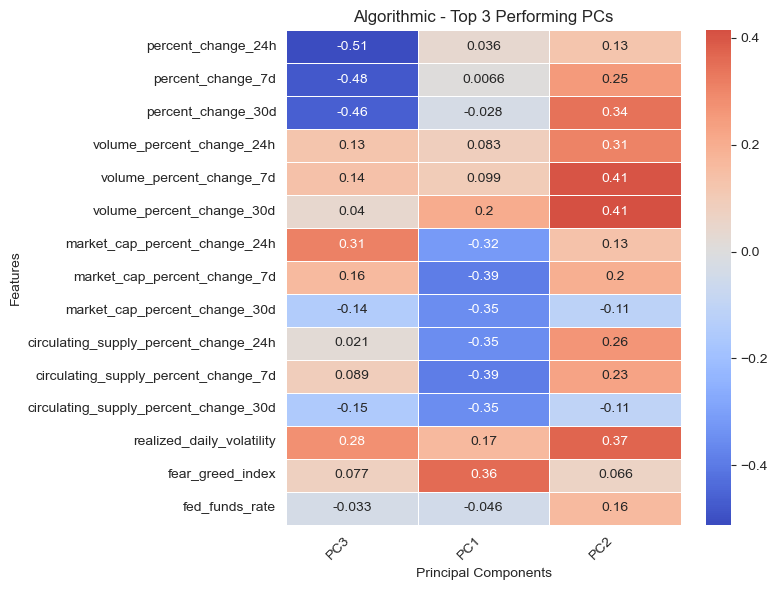

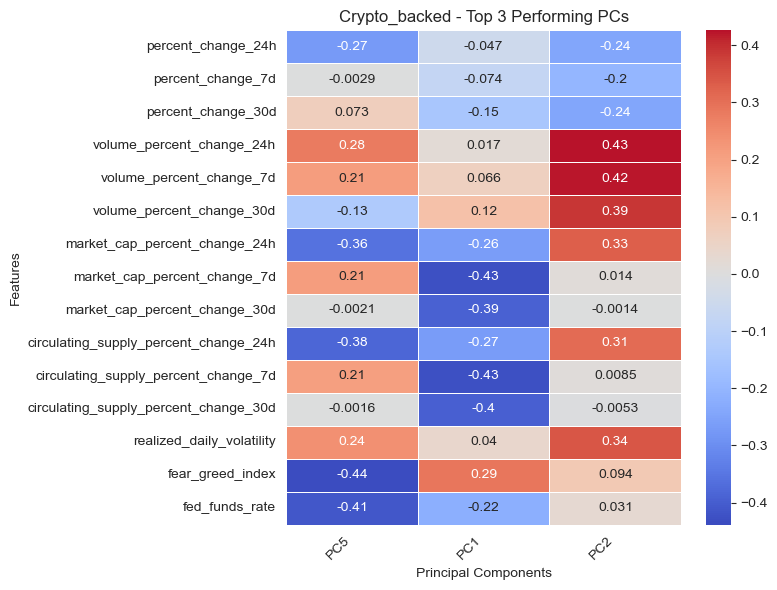

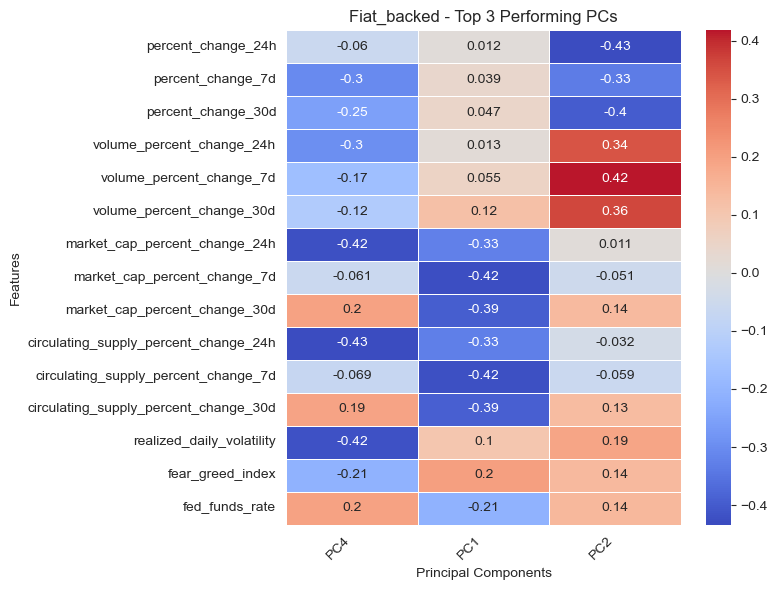

In [77]:
# =========================
# HEATMAPS FOR TOP 3 PCs
# =========================

import seaborn as sns

for coin_type, pca in pca_models.items():
    
    pcs = top3_pcs[top3_pcs["coin_type"] == coin_type]["pc_index"].tolist()
    
    if len(pcs) == 0:
        continue

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    selected_cols = [f'PC{i+1}' for i in pcs]
    loadings_top3 = loadings_df[selected_cols]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        loadings_top3,
        cmap='coolwarm',
        center=0,
        annot=True,
        linewidths=0.5
    )

    plt.title(f"{coin_type.capitalize()} - Top 3 Performing PCs")
    plt.xlabel("Principal Components")
    plt.ylabel("Features")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [78]:
print(df.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

depeg    0   1
coin          
dai    480  21
pax    497   4
usdc   468  33
usdt   470  31
ust    469  32


In [79]:
#check depeg events
for coin, group in df.groupby("coin"):
    depegs = group[group["depeg"] == 1]["timestamp"]
    print(f"{coin}: {len(depegs)} depegs | earliest={depegs.min().date()} | latest={depegs.max().date()}")

dai: 21 depegs | earliest=2021-01-01 | latest=2021-12-28
pax: 4 depegs | earliest=2021-04-17 | latest=2021-09-09
usdc: 33 depegs | earliest=2021-01-07 | latest=2022-02-07
usdt: 31 depegs | earliest=2020-12-26 | latest=2021-12-10
ust: 32 depegs | earliest=2020-12-30 | latest=2022-05-09


Limitation of doing a global split:
Dropping PAX and USDT from depeg evaluation, keep them in PCA. They contribute to learning the fiat-backed covariance structure in PCA, but since they have no test depegs you just can't evaluate anomaly detection on them.
